# 67070238 — Banking Analytics: Credit Card Customer

วิเคราะห์ข้อมูลลูกค้าบัตรเครดิต `CreditCardCustomer.csv` (10,127 ราย) ตามโจทย์ 2 ส่วน

**Part 1** สร้างโมเดล 3 เคส
- **Case 1** Churn Prediction — ทำนายลูกค้าที่เสี่ยงยกเลิกบัตร (classification)
- **Case 2** Up-selling — ให้คะแนนลูกค้า Blue ที่โปรไฟล์คล้ายผู้ถือบัตรพรีเมียม (lookalike scoring)
- **Case 3** Credit Limit — ประมาณวงเงินที่เหมาะสมจากพฤติกรรมการใช้งาน (regression)

**Part 2** ตอบคำถาม TA 2 ข้อจากผล EDA

โมเดลที่ใช้: **Logistic Regression** เป็น baseline และ **Histogram-based Gradient Boosting** เป็นโมเดลหลัก

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             RocCurveDisplay, ConfusionMatrixDisplay,
                             mean_absolute_error, root_mean_squared_error, r2_score)

sns.set_theme(style="whitegrid", font="Sarabun")
plt.rcParams["font.family"] = ["Sarabun", "Thonburi"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
SEED = 7

In [2]:
df = pd.read_csv("CreditCardCustomer.csv")
print("ขนาดข้อมูล:", df.shape)
df.sample(5, random_state=SEED)

ขนาดข้อมูล: (10127, 21)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
2914,718318383,Existing Customer,49,M,1,High School,Unknown,$60K - $80K,Blue,36,...,3,4,2645.0,1499,1146.0,0.670,4251,69,0.533,0.567
1592,714248733,Existing Customer,26,F,0,Unknown,Single,Unknown,Blue,13,...,1,2,4395.0,1240,3155.0,0.662,2272,46,0.438,0.282
3577,721462458,Existing Customer,52,F,3,High School,Married,Unknown,Blue,42,...,2,1,23858.0,1179,22679.0,0.671,3784,69,0.683,0.049
6390,790164408,Existing Customer,59,F,1,Unknown,Married,Less than $40K,Blue,52,...,3,3,2308.0,2094,214.0,0.722,4869,77,0.750,0.907
4106,720029508,Existing Customer,50,F,1,Graduate,Single,$40K - $60K,Blue,37,...,1,0,12064.0,1312,10752.0,0.462,4100,67,0.675,0.109


## 1. สำรวจข้อมูล (EDA)

In [3]:
print(df.dtypes.value_counts(), "\n")
print("NaN ทั้งหมด:", df.isna().sum().sum())

cat_cols = df.select_dtypes(include="object").columns
for c in cat_cols:
    vals = df[c].value_counts()
    unk = vals.get("Unknown", 0)
    print(f"{c}: {df[c].nunique()} ค่า" + (f" (Unknown {unk} แถว)" if unk else ""))

int64      10
object      6
float64     5
Name: count, dtype: int64 

NaN ทั้งหมด: 0
Attrition_Flag: 2 ค่า
Gender: 2 ค่า
Education_Level: 7 ค่า (Unknown 1519 แถว)
Marital_Status: 4 ค่า (Unknown 749 แถว)
Income_Category: 6 ค่า (Unknown 1112 แถว)
Card_Category: 4 ค่า


ข้อมูลไม่มี NaN แต่มีค่า `Unknown` แฝงอยู่ใน Education_Level / Marital_Status / Income_Category
→ เลือกเก็บ Unknown ไว้เป็นหมวดหมู่หนึ่งแทนการลบทิ้ง เพราะถ้าลบจะเสียข้อมูลรวมกันหลายพันแถว

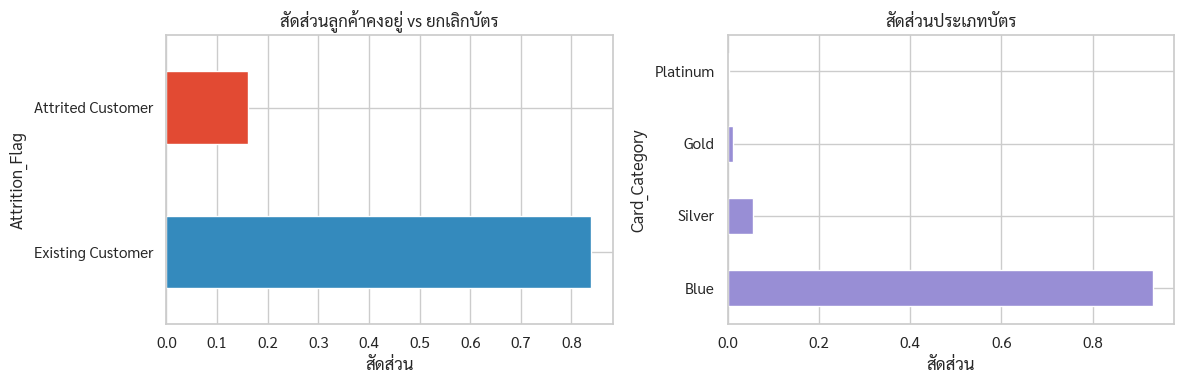

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64


In [4]:
# สัดส่วนตัวแปรเป้าหมายของ Case 1 และ Case 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Attrition_Flag"].value_counts(normalize=True).plot.barh(ax=axes[0], color=["#348ABD", "#E24A33"])
axes[0].set_title("สัดส่วนลูกค้าคงอยู่ vs ยกเลิกบัตร")
axes[0].set_xlabel("สัดส่วน")

df["Card_Category"].value_counts(normalize=True).plot.barh(ax=axes[1], color="#988ED5")
axes[1].set_title("สัดส่วนประเภทบัตร")
axes[1].set_xlabel("สัดส่วน")
plt.tight_layout()
plt.show()

print(df["Attrition_Flag"].value_counts())
print()
print(df["Card_Category"].value_counts())

ทั้งสองเป้าหมาย **imbalanced ชัดเจน** — churn มีแค่ ~16% และบัตรพรีเมียมรวมกันมีแค่ ~7%
ตอนเทรนโมเดลจึงต้องใช้ `class_weight="balanced"` และประเมินด้วย recall/F1/ROC-AUC แทน accuracy

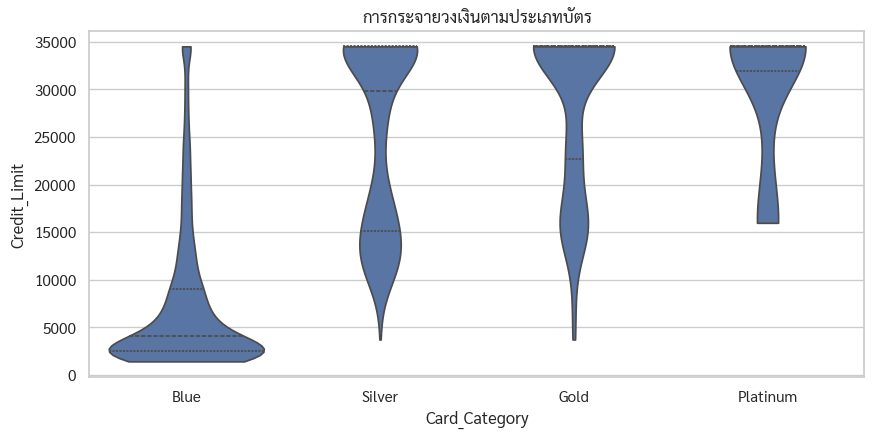

,count,min,median,max
Card_Category,,,,
Blue,9436,1438.0,4105.0,34516.0
Silver,555,3735.0,29808.0,34516.0
Gold,116,3735.0,34516.0,34516.0
Platinum,20,15987.0,34516.0,34516.0


In [5]:
# ความสัมพันธ์ Credit_Limit กับ Card_Category (เก็บไว้ตอบ Part 2 ข้อ 1)
order = ["Blue", "Silver", "Gold", "Platinum"]
plt.figure(figsize=(10, 4.5))
sns.violinplot(data=df, x="Card_Category", y="Credit_Limit", order=order, cut=0, inner="quartile")
plt.title("การกระจายวงเงินตามประเภทบัตร")
plt.show()

df.groupby("Card_Category")["Credit_Limit"].agg(["count", "min", "median", "max"]).loc[order].round(0)

จุดที่สะดุดตา: วงเงิน **max ของทุกประเภทบัตรคือ 34,516 เท่ากันหมด** (โดน cap) และลูกค้า Blue จำนวนไม่น้อยมีวงเงินสูงกว่าค่ากลางของ Silver → วงเงินกับระดับบัตรไม่ได้ไล่ขั้นกันตามตรรกะธุรกิจ (วิเคราะห์เต็ม ๆ ใน Part 2)

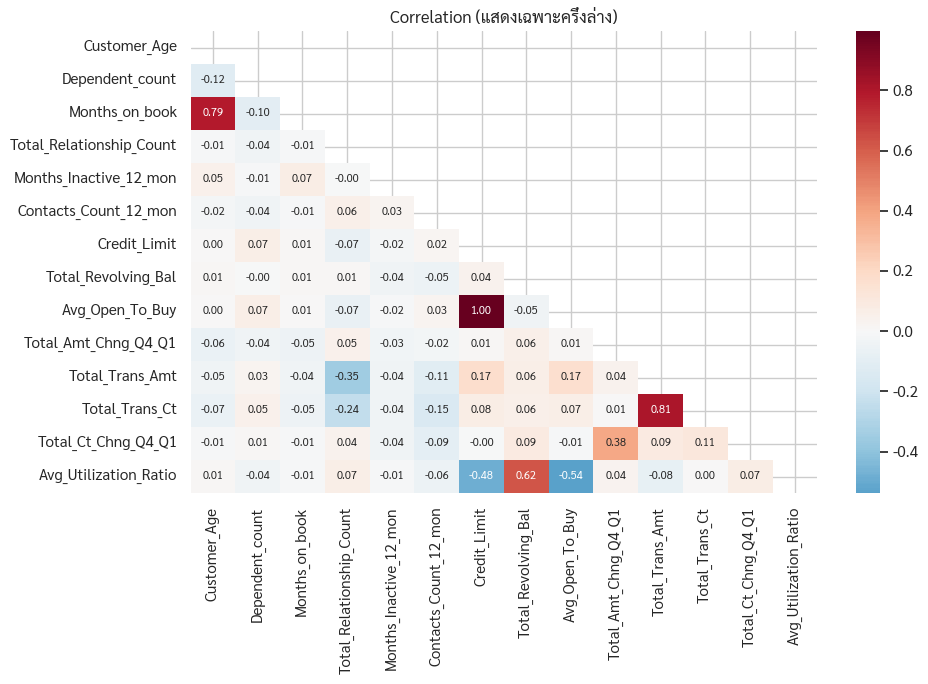

corr(Credit_Limit, Avg_Open_To_Buy) = 0.996


In [6]:
# ตรวจ correlation เพื่อหา feature ที่ derive มาจากกันเอง (leakage)
num = df.drop(columns="CLIENTNUM").select_dtypes(include=np.number)
corr = num.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, annot_kws={"size": 8})
plt.title("Correlation (แสดงเฉพาะครึ่งล่าง)")
plt.tight_layout()
plt.show()

print("corr(Credit_Limit, Avg_Open_To_Buy) =", corr.loc["Credit_Limit", "Avg_Open_To_Buy"].round(4))

พบคู่ feature ที่คำนวณมาจากกันเองโดยตรง ต้องระวังเป็น data leakage:
- `Avg_Open_To_Buy` = Credit_Limit − Total_Revolving_Bal (corr ≈ 1.00)
- `Avg_Utilization_Ratio` = Total_Revolving_Bal ÷ Credit_Limit

ถ้าเป้าหมายคือทำนาย Credit_Limit (Case 3) สองตัวนี้คือ "เฉลยที่แปลงร่างมา" ต้องตัดออก

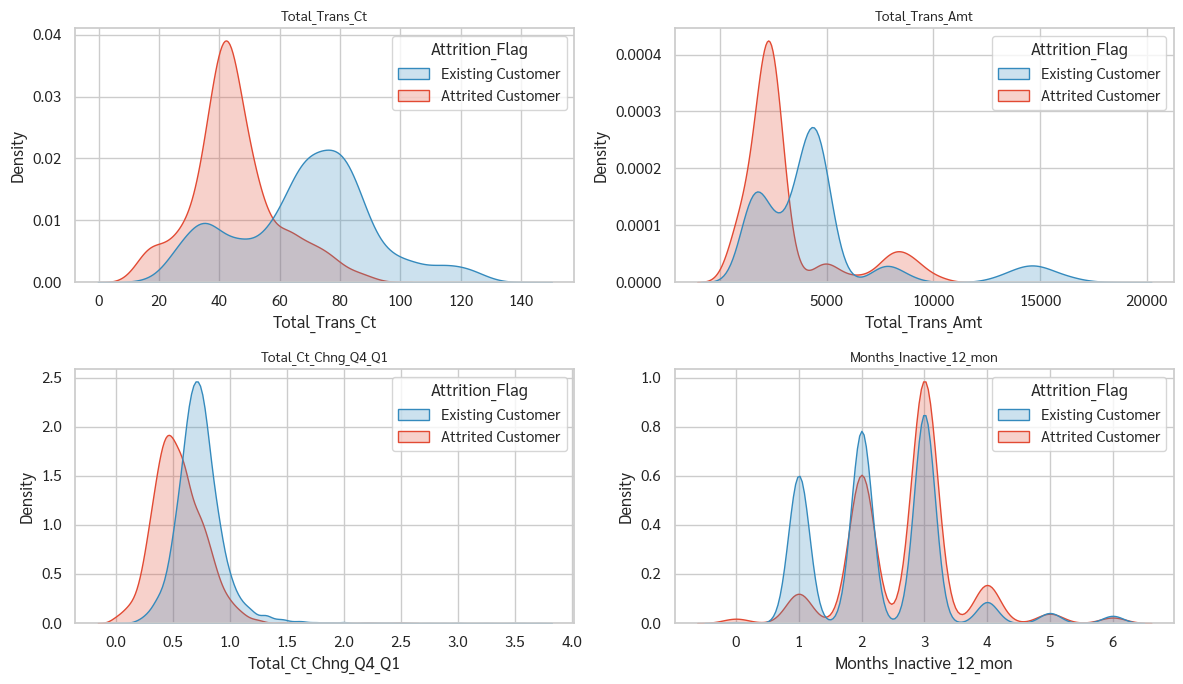

In [7]:
# เปรียบเทียบพฤติกรรมระหว่างลูกค้าที่อยู่ต่อกับที่ยกเลิก
feats = ["Total_Trans_Ct", "Total_Trans_Amt", "Total_Ct_Chng_Q4_Q1", "Months_Inactive_12_mon"]
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, f in zip(axes.ravel(), feats):
    sns.kdeplot(data=df, x=f, hue="Attrition_Flag", common_norm=False, fill=True, ax=ax,
                palette={"Existing Customer": "#348ABD", "Attrited Customer": "#E24A33"})
    ax.set_title(f, fontsize=10)
plt.tight_layout()
plt.show()

ลูกค้าที่ยกเลิกบัตรใช้จ่ายน้อยกว่า ธุรกรรมน้อยกว่า และอัตราการเปลี่ยนแปลงจำนวนธุรกรรม Q4/Q1 ต่ำกว่าอย่างเห็นได้ชัด → พฤติกรรมการใช้บัตรคือสัญญาณหลักของการ churn

---
## 2. Case 1: Customer Churn Prediction

แผนการทำ:
- target: `Attrition_Flag` (Attrited = 1) / ตัด `CLIENTNUM` ทิ้ง / one-hot encode ตัวแปรหมวดหมู่
- แบ่ง train/test 80:20 แบบ stratified
- baseline: **Logistic Regression** → โมเดลหลัก: **HistGradientBoostingClassifier** (`class_weight="balanced"` ทั้งคู่)
- ตัวชี้วัดหลักคือ **recall ของกลุ่ม Attrited** เพราะปล่อยลูกค้าหลุด (false negative) แพงกว่าส่งโปรโมชันเกินจำเป็น

In [8]:
y = (df["Attrition_Flag"] == "Attrited Customer").astype(int)
X = pd.get_dummies(df.drop(columns=["CLIENTNUM", "Attrition_Flag"]), drop_first=True)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f"train {X_tr.shape} | test {X_te.shape} | churn rate (train) {y_tr.mean():.1%}")

train (8101, 32) | test (2026, 32) | churn rate (train) 16.1%


In [9]:
# baseline
sc = StandardScaler().fit(X_tr)
lr = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
lr.fit(sc.transform(X_tr), y_tr)
p_lr = lr.predict_proba(sc.transform(X_te))[:, 1]

print("--- Logistic Regression (baseline) ---")
print(classification_report(y_te, (p_lr >= 0.5).astype(int), target_names=["Existing", "Attrited"]))
print("ROC-AUC:", round(roc_auc_score(y_te, p_lr), 4))

--- Logistic Regression (baseline) ---
              precision    recall  f1-score   support

    Existing       0.96      0.85      0.90      1701
    Attrited       0.51      0.83      0.63       325

    accuracy                           0.84      2026
   macro avg       0.74      0.84      0.77      2026
weighted avg       0.89      0.84      0.86      2026

ROC-AUC: 0.9191


/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/opt/homebrew/lib/python3.10/site-packages/sklearn/l

In [10]:
# โมเดลหลัก
gb = HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED)
gb.fit(X_tr, y_tr)
p_gb = gb.predict_proba(X_te)[:, 1]

print("--- HistGradientBoosting ---")
print(classification_report(y_te, gb.predict(X_te), target_names=["Existing", "Attrited"]))
print("ROC-AUC:", round(roc_auc_score(y_te, p_gb), 4))

--- HistGradientBoosting ---
              precision    recall  f1-score   support

    Existing       0.98      0.98      0.98      1701
    Attrited       0.90      0.91      0.90       325

    accuracy                           0.97      2026
   macro avg       0.94      0.94      0.94      2026
weighted avg       0.97      0.97      0.97      2026

ROC-AUC: 0.993


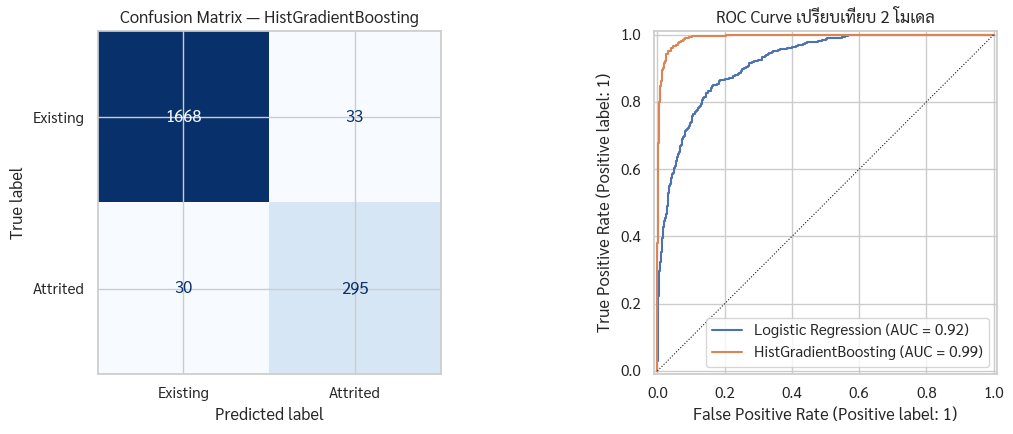

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_te, gb.predict(X_te)),
                       display_labels=["Existing", "Attrited"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix — HistGradientBoosting")

RocCurveDisplay.from_predictions(y_te, p_lr, name="Logistic Regression", ax=axes[1])
RocCurveDisplay.from_predictions(y_te, p_gb, name="HistGradientBoosting", ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k:", lw=0.8)
axes[1].set_title("ROC Curve เปรียบเทียบ 2 โมเดล")
plt.tight_layout()
plt.show()

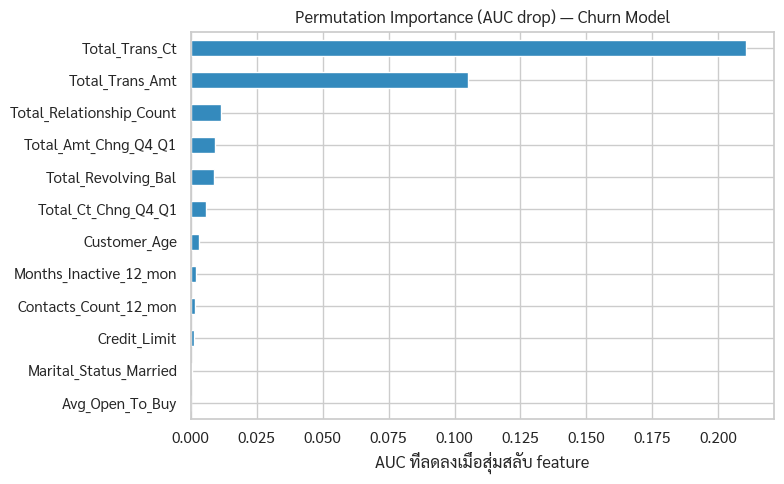

In [12]:
# HistGB ไม่มี feature_importances_ ในตัว จึงใช้ permutation importance บนชุด test แทน
# (สุ่มสลับค่าทีละ feature แล้วดูว่า AUC ตกลงเท่าไร — ตกมาก = feature สำคัญ)
pi = permutation_importance(gb, X_te, y_te, scoring="roc_auc", n_repeats=5,
                            random_state=SEED, n_jobs=-1)
top = pd.Series(pi.importances_mean, index=X.columns).nlargest(12)
top.sort_values().plot.barh(figsize=(8, 5), color="#348ABD")
plt.title("Permutation Importance (AUC drop) — Churn Model")
plt.xlabel("AUC ที่ลดลงเมื่อสุ่มสลับ feature")
plt.tight_layout()
plt.show()

**สรุป Case 1:** HistGradientBoosting ชนะ baseline ทุกตัวชี้วัด และ permutation importance ยืนยันว่าตัวทำนายหลักคือพฤติกรรมการใช้บัตร (Total_Trans_Ct, Total_Trans_Amt, Total_Revolving_Bal, Total_Ct_Chng_Q4_Q1) ไม่ใช่ข้อมูลส่วนตัว → ธนาคารใช้ probability จากโมเดลจัดอันดับลูกค้าเข้า Retention Program ได้ทันที

---
## 3. Case 2: Up-selling Lookalike

แผนการทำ:
- label: Premium (Silver/Gold/Platinum) = 1 vs Blue = 0
- **ตัด `Credit_Limit` และ `Avg_Open_To_Buy` ออก** — วงเงินผูกกับประเภทบัตรเชิงนโยบาย ถ้าใส่เข้าไปโมเดลจะเรียนรู้กติกาธนาคารแทนพฤติกรรมลูกค้า (ประเด็นเดียวกับ Part 2 ข้อ 1)
- ให้คะแนนลูกค้า Blue ด้วย **out-of-fold prediction (5-fold)** — ห้ามให้โมเดลให้คะแนนข้อมูลที่ตัวเองเคยเห็นตอนเทรน เพราะคะแนนจะเอนเอียง
- จัดอันดับแล้วตัด top-N ตามงบแคมเปญ

In [13]:
df["Is_Premium"] = df["Card_Category"].isin(["Silver", "Gold", "Platinum"]).astype(int)

X2 = pd.get_dummies(
    df.drop(columns=["CLIENTNUM", "Card_Category", "Is_Premium", "Credit_Limit", "Avg_Open_To_Buy"]),
    drop_first=True)
y2 = df["Is_Premium"]

X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.2, stratify=y2, random_state=SEED)

gb_up = HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED)
gb_up.fit(X2_tr, y2_tr)

print("--- Premium vs Blue ---")
print(classification_report(y2_te, gb_up.predict(X2_te), target_names=["Blue", "Premium"]))
print("ROC-AUC:", round(roc_auc_score(y2_te, gb_up.predict_proba(X2_te)[:, 1]), 4))

--- Premium vs Blue ---
              precision    recall  f1-score   support

        Blue       0.98      0.95      0.97      1888
     Premium       0.53      0.71      0.61       138

    accuracy                           0.94      2026
   macro avg       0.76      0.83      0.79      2026
weighted avg       0.95      0.94      0.94      2026

ROC-AUC: 0.9419


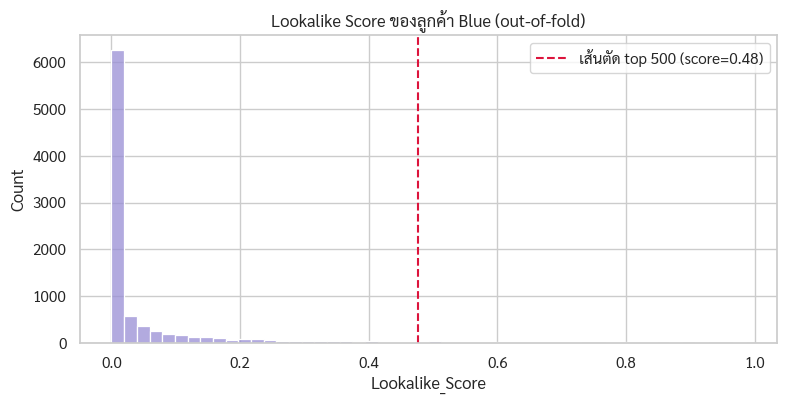

กลุ่มเป้าหมายแคมเปญ = top 500 จาก Blue ทั้งหมด 9,436 ราย


,CLIENTNUM,Customer_Age,Income_Category,Total_Trans_Amt,Total_Trans_Ct,Lookalike_Score
8776,708153558,46,$120K +,7936,101,0.985623
9024,709619433,52,$120K +,8604,108,0.983050
9999,778956033,51,$80K - $120K,15151,104,0.980706
2565,712206858,39,$120K +,3094,45,0.979721
9704,714912408,45,$80K - $120K,14917,88,0.976737
9841,715601808,50,$120K +,16692,131,0.976088
4739,712309758,65,$40K - $60K,4351,75,0.974841
8639,718665933,43,$120K +,7437,86,0.974787
9383,712952283,50,$120K +,14474,121,0.971200
2677,809984133,37,$120K +,2730,68,0.969898


In [14]:
# out-of-fold lookalike score สำหรับลูกค้า Blue ทุกคน
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof = cross_val_predict(gb_up, X2, y2, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

blue = df["Card_Category"] == "Blue"
targets = df.loc[blue, ["CLIENTNUM", "Customer_Age", "Income_Category",
                        "Total_Trans_Amt", "Total_Trans_Ct"]].copy()
targets["Lookalike_Score"] = oof[blue.values]
targets = targets.sort_values("Lookalike_Score", ascending=False)

TOP_N = 500
cut = targets["Lookalike_Score"].iloc[TOP_N - 1]

plt.figure(figsize=(9, 4))
sns.histplot(targets["Lookalike_Score"], bins=50, color="#988ED5")
plt.axvline(cut, color="crimson", ls="--", label=f"เส้นตัด top {TOP_N} (score={cut:.2f})")
plt.title("Lookalike Score ของลูกค้า Blue (out-of-fold)")
plt.legend()
plt.show()

print(f"กลุ่มเป้าหมายแคมเปญ = top {TOP_N} จาก Blue ทั้งหมด {blue.sum():,} ราย")
targets.head(10)

**สรุป Case 2:** โมเดลแยกโปรไฟล์พรีเมียมออกจาก Blue ได้ดี และคะแนน out-of-fold ทำให้จัดอันดับได้อย่างยุติธรรม ทีมการตลาดเลือกขนาดกลุ่มเป้าหมายได้ตามงบ (สาธิตที่ 500 ราย) แทนการยิงแคมเปญใส่ Blue ทั้ง 9,436 ราย

---
## 4. Case 3: Predictive Credit Limit

แผนการทำ:
- target: `Credit_Limit` — การกระจายเบ้ขวาแรง จึงเทรนบน **log scale** แล้วแปลงกลับตอนวัดผล
- ตัด leakage: `Avg_Open_To_Buy`, `Avg_Utilization_Ratio` (คำนวณจาก target โดยตรง) และ `Card_Category` (กำหนดจากวงเงิน — งูกินหาง)
- โมเดล: **HistGradientBoostingRegressor** วัดด้วย MAE / RMSE / R²

In [15]:
X3 = pd.get_dummies(
    df.drop(columns=["CLIENTNUM", "Is_Premium", "Card_Category",
                     "Credit_Limit", "Avg_Open_To_Buy", "Avg_Utilization_Ratio"]),
    drop_first=True)
y3_log = np.log1p(df["Credit_Limit"])

X3_tr, X3_te, y3_tr, y3_te = train_test_split(X3, y3_log, test_size=0.2, random_state=SEED)

gb_lim = HistGradientBoostingRegressor(random_state=SEED)
gb_lim.fit(X3_tr, y3_tr)

pred = np.expm1(gb_lim.predict(X3_te))
actual = np.expm1(y3_te)

print(f"MAE : {mean_absolute_error(actual, pred):,.0f}")
print(f"RMSE: {root_mean_squared_error(actual, pred):,.0f}")
print(f"R²  : {r2_score(actual, pred):.4f}")

MAE : 4,704
RMSE: 7,482
R²  : 0.3268


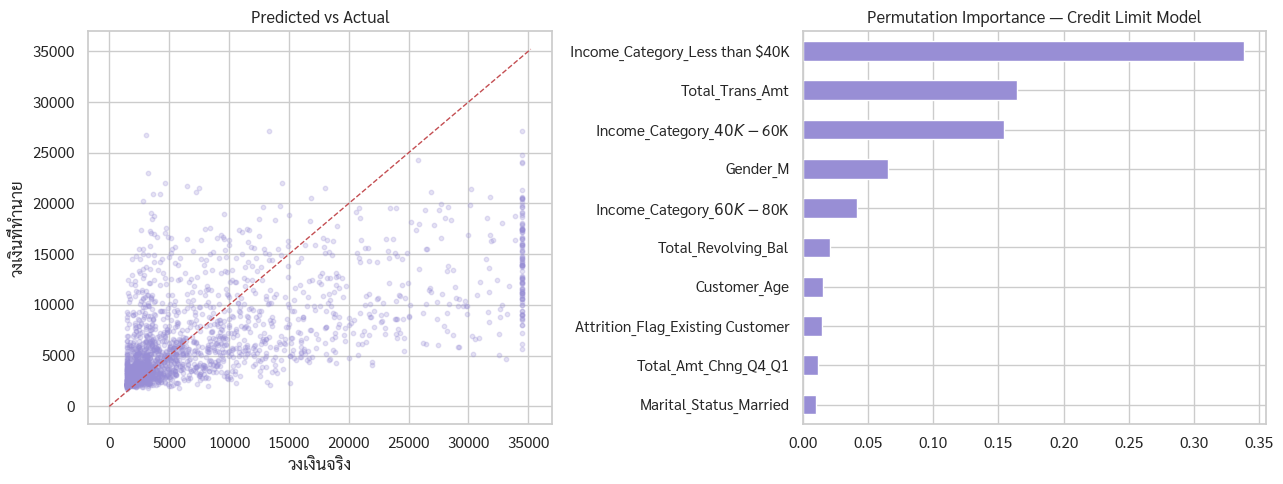

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(actual, pred, s=10, alpha=0.25, color="#988ED5")
mx = actual.max() * 1.02
axes[0].plot([0, mx], [0, mx], "r--", lw=1)
axes[0].set(xlabel="วงเงินจริง", ylabel="วงเงินที่ทำนาย", title="Predicted vs Actual")

pi3 = permutation_importance(gb_lim, X3_te, y3_te, n_repeats=5, random_state=SEED, n_jobs=-1)
pd.Series(pi3.importances_mean, index=X3.columns).nlargest(10).sort_values().plot.barh(
    ax=axes[1], color="#988ED5")
axes[1].set_title("Permutation Importance — Credit Limit Model")
plt.tight_layout()
plt.show()

**สรุป Case 3:** ปัจจัยหลักที่โมเดลใช้คือรายได้และเพศ ตามด้วยพฤติกรรมใช้จ่าย ค่า R² อยู่ในระดับปานกลางซึ่งอธิบายได้ — วงเงินจริงในข้อมูลถูกกำหนดโดยนโยบายธนาคาร (มีเพดาน 34,516) ไม่ได้มาจากพฤติกรรมล้วน ๆ การใช้งานจริงจึงควรใช้ค่าทำนายเป็น **วงเงินแนะนำเบื้องต้น** ให้เจ้าหน้าที่สินเชื่อพิจารณาประกอบ เพื่อคุมความเสี่ยง NPL

---
## 5. Part 2: ตอบคำถาม TA

### ข้อ 1 — ความไม่สอดคล้องระหว่าง `Credit_Limit` กับ `Card_Category`

In [17]:
blue_df = df[df["Card_Category"] == "Blue"]
silver_median = df.loc[df["Card_Category"] == "Silver", "Credit_Limit"].median()

print(f"ค่ากลางวงเงิน Silver = {silver_median:,.0f}")
print(f"ลูกค้า Blue ที่วงเงิน >= ค่ากลาง Silver: {(blue_df['Credit_Limit'] >= silver_median).sum()} ราย "
      f"({(blue_df['Credit_Limit'] >= silver_median).mean():.1%} ของ Blue)")
print(f"ลูกค้า Blue ที่วงเงินชนเพดาน 34,516: {(blue_df['Credit_Limit'] == 34516).sum()} ราย")
print(f"จำนวนลูกค้าแต่ละประเภท: Blue {len(blue_df):,} / Silver 555 / Gold 116 / Platinum 20")

ค่ากลางวงเงิน Silver = 29,808
ลูกค้า Blue ที่วงเงิน >= ค่ากลาง Silver: 313 ราย (3.3% ของ Blue)
ลูกค้า Blue ที่วงเงินชนเพดาน 34,516: 198 ราย
จำนวนลูกค้าแต่ละประเภท: Blue 9,436 / Silver 555 / Gold 116 / Platinum 20


**คำตอบข้อ 1**

ความไม่สอดคล้องที่พบจาก EDA:
1. ตามตรรกะธุรกิจ บัตรระดับสูงควรมาพร้อมวงเงินสูงกว่าเป็นลำดับขั้น แต่ข้อมูลจริงมีลูกค้า Blue หลายร้อยรายที่วงเงินสูงกว่าค่ากลางของ Silver และบางรายวงเงิน**ชนเพดานเดียวกับ Platinum (34,516)**
2. ค่า max = 34,516 เท่ากันทุกประเภทบัตร บ่งชี้ว่าเป็น**เพดานที่ระบบ cap ไว้** ไม่ใช่วงเงินตามธรรมชาติ
3. ขนาดกลุ่มเหลื่อมกันมาก (Blue 9,436 vs Platinum 20) สถิติฝั่งพรีเมียมจึงเชื่อถือได้ต่ำ

ผลเสียถ้าใช้สองคอลัมน์นี้ร่วมกันโดยไม่ปรับแต่ง:
- **ความแม่นยำ:** เกิด multicollinearity ระหว่าง feature ที่เล่าเรื่องเดียวกัน และถ้าใช้ตัวหนึ่งทำนายอีกตัว (เช่น Case 2/3) จะเป็น data leakage — คะแนน validation สวยเกินจริง แต่พังทันทีเมื่อเจอลูกค้าที่วงเงินยังไม่ถูกกำหนด
- **ตรรกะธุรกิจ:** โมเดลจะเรียนรู้ "กติกาการออกบัตรของธนาคาร" แทน "พฤติกรรมลูกค้า" เช่น สรุปว่า Blue วงเงินสูงคือว่าที่ลูกค้าพรีเมียม ทั้งที่คนกลุ่มนั้นอาจได้วงเงินสูงจากฐานรายได้เฉย ๆ โดยไม่มีพฤติกรรมใช้จ่ายแบบพรีเมียมเลย → แคมเปญหลงเป้า

แนวทางที่ใช้ในงานนี้: Case 2 ตัด Credit_Limit/Avg_Open_To_Buy ออก และ Case 3 ตัด Card_Category ออก เพื่อบังคับให้โมเดลเรียนรู้จากพฤติกรรมจริงเท่านั้น

### ข้อ 2 — โมเดลใช้กับลูกค้าใหม่ที่ยังไม่เคยรูดบัตรได้หรือไม่?

พิสูจน์ด้วยการทดลอง: เทรนโมเดล churn อีกตัวโดยใช้เฉพาะข้อมูลที่มี ณ วันสมัครบัตร

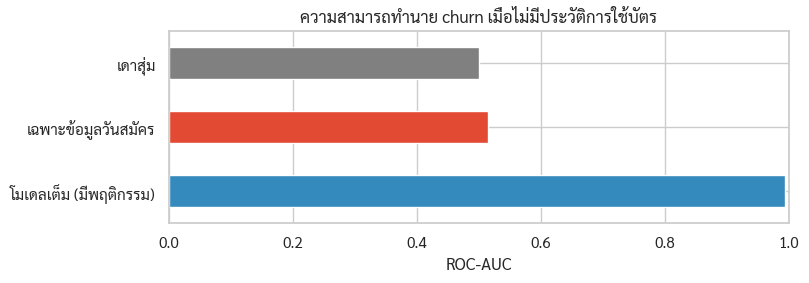

โมเดลเต็ม (มีพฤติกรรม)    0.993
เฉพาะข้อมูลวันสมัคร       0.515
เดาสุ่ม                   0.500
dtype: float64


In [18]:
apply_day_cols = ["Customer_Age", "Gender", "Dependent_count",
                  "Education_Level", "Marital_Status", "Income_Category"]
Xd = pd.get_dummies(df[apply_day_cols], drop_first=True)

Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, y, test_size=0.2, stratify=y, random_state=SEED)

gb_cold = HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED)
gb_cold.fit(Xd_tr, yd_tr)

auc_cold = roc_auc_score(yd_te, gb_cold.predict_proba(Xd_te)[:, 1])
auc_full = roc_auc_score(y_te, p_gb)

comp = pd.Series({"โมเดลเต็ม (มีพฤติกรรม)": auc_full,
                  "เฉพาะข้อมูลวันสมัคร": auc_cold,
                  "เดาสุ่ม": 0.5})
comp.plot.barh(figsize=(8, 2.5), color=["#348ABD", "#E24A33", "grey"])
plt.xlabel("ROC-AUC")
plt.title("ความสามารถทำนาย churn เมื่อไม่มีประวัติการใช้บัตร")
plt.xlim(0, 1)
plt.show()
print(comp.round(4))

**คำตอบข้อ 2**

**ใช้ไม่ได้** ด้วยเหตุผล 2 ชั้น:
1. **เชิงเทคนิค (Cold-Start Problem):** feature ที่โมเดลพึ่งพามากที่สุดล้วนเป็นสถิติย้อนหลัง 12 เดือน (Total_Trans_Ct, Total_Trans_Amt, Months_Inactive_12_mon ฯลฯ) ลูกค้าใหม่มีค่าเหล่านี้เป็น 0/ว่างทั้งหมด โมเดลยังคืนตัวเลขออกมาได้ แต่เป็นการทำนายบนข้อมูลที่ไม่มีความหมาย
2. **เชิงประจักษ์:** จากการทดลองด้านบน เมื่อเหลือเฉพาะข้อมูลวันสมัคร AUC ร่วงจาก ~0.99 ลงมาแทบเท่าเดาสุ่ม (~0.5) — ข้อมูล demographic เพียงอย่างเดียวแทบไม่มีอำนาจทำนาย churn

การปรับกลยุทธ์ feature selection ให้ใช้งานได้จริง:
1. **แยกเป็น 2 โมเดลตามอายุลูกค้า** — โมเดล cold-start สำหรับลูกค้าใหม่ (ใช้ข้อมูลวันสมัคร + แหล่งภายนอก เช่น เครดิตบูโร) และโมเดลเต็มสำหรับลูกค้าที่มีประวัติครบ
2. **สร้าง feature ระยะสั้น** ที่เกิดเร็ว เช่น เปิดใช้บัตรภายในกี่วัน จำนวนธุรกรรม 30/60/90 วันแรก การสมัคร mobile banking — ให้โมเดลเริ่มทำนายได้ตั้งแต่เดือนแรก ๆ
3. **ยอมรับ trade-off:** โมเดล cold-start ความแม่นยำต่ำกว่า จึงเหมาะกับการ screening กว้าง ๆ แล้วส่งต่อให้โมเดลเต็มเมื่อลูกค้ามีประวัติครบ 3–6 เดือน